<a href="https://colab.research.google.com/github/romeurf/DipRadar/blob/main/DipRadar_v31_Retrain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DipRadar v3.1 — Retrain Notebook

**Objectivo:** reconstruir `ml_training_merged.parquet` com schema completo v3.1 e treinar um novo bundle `dip_models_v3.pkl` pronto a fazer upload para o repo.

## Fluxo
| Célula | O que faz |
|---|---|
| 1 | Setup (clone repo + instalar deps) |
| 2 | Verificar parquet base (schema + estatísticas) |
| 3 | Fetch de preços OHLCV (yfinance) |
| 4 | Construir dataset v3.1 (27 features + targets) |
| 5 | Inspecionar dataset — distribuições + NaN |
| 6 | Walk-forward CV — comparar modelos |
| 7 | Champion + calibrator + bundle final |
| 8 | Inspecionar bundle + smoke test |
| 9 | Upload para GitHub |

> **Sem fallbacks:** qualquer erro em qualquer célula deve ser resolvido antes de continuar.

In [1]:
import subprocess, sys, os

REPO_URL = 'https://github.com/romeurf/DipRadar.git'
REPO_DIR = '/content/DipRadar'

if not os.path.isdir(REPO_DIR):
    subprocess.run(['git', 'clone', REPO_URL, REPO_DIR], check=True)
else:
    subprocess.run(['git', '-C', REPO_DIR, 'pull', '--ff-only'], check=True)

os.chdir(REPO_DIR)
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

deps = [
    'yfinance>=0.2.40',
    'xgboost>=2.0',
    'lightgbm>=4.0',
    'scikit-learn>=1.4',
    'joblib',
    'pandas>=2.0',
    'pyarrow',
    'scipy',
    'requests',
]
subprocess.run([sys.executable, '-m', 'pip', 'install', '--quiet', *deps], check=True)

print(f'✓ Repo: {REPO_DIR}')
print(f'✓ cwd:  {os.getcwd()}')
print('✓ Dependências instaladas')


✓ Repo: /content/DipRadar
✓ cwd:  /content/DipRadar
✓ Dependências instaladas


In [2]:
from pathlib import Path
import pandas as pd

PARQUET_BASE = Path(REPO_DIR) / 'ml_training_merged.parquet'
assert PARQUET_BASE.exists(), f'ERRO: parquet base não encontrado em {PARQUET_BASE}'

raw = pd.read_parquet(PARQUET_BASE)
print(f'Shape:   {raw.shape}')
print(f'Colunas: {sorted(raw.columns.tolist())}')

from build_training_dataset import _normalise_base_df
base_df = _normalise_base_df(raw)

print(f'\n✓ Após normalização:')
print(f'  Linhas:  {len(base_df)}')
print(f'  Tickers: {base_df["ticker"].nunique()}')
print(f'  Período: {base_df["alert_date"].min().date()} → {base_df["alert_date"].max().date()}')
print(f'  Sectores: {sorted(base_df["sector"].unique())}')

HAS_TARGET = 'max_return_60d' in base_df.columns
HAS_PRICE  = 'price' in base_df.columns
print(f'\n  max_return_60d presente: {HAS_TARGET}')
print(f'  price presente:          {HAS_PRICE}')

if not HAS_TARGET and not HAS_PRICE:
    raise ValueError('ERRO: parquet base sem max_return_60d nem price.\nbuild_dataset_v31 vai descartar todas as linhas.')

display(base_df.head(3))


Shape:   (17368, 27)
Colunas: ['alert_date', 'analyst_upside', 'atr_ratio', 'de_ratio', 'drawdown_52w', 'drop_pct_today', 'fcf_yield', 'gross_margin', 'label_further_drop', 'label_win', 'macro_score', 'market_cap_b', 'outcome_label', 'pe_vs_fair', 'price', 'quality_score', 'return_3m', 'return_6m', 'revenue_growth', 'rsi_14', 'sector', 'sector_drawdown_5d', 'spy_drawdown_5d', 'spy_return_ref', 'symbol', 'vix', 'volume_spike']

✓ Após normalização:
  Linhas:  17368
  Tickers: 762
  Período: 2006-05-19 → 2026-01-13
  Sectores: ['Basic Materials', 'Communication Services', 'Consumer Cyclical', 'Consumer Defensive', 'Energy', 'Financial Services', 'Healthcare', 'Industrials', 'Real Estate', 'Technology', 'Unknown', 'Utilities']

  max_return_60d presente: False
  price presente:          True


,macro_score,vix,spy_drawdown_5d,sector_drawdown_5d,fcf_yield,revenue_growth,gross_margin,de_ratio,pe_vs_fair,analyst_upside,...,alert_date,price,label_win,label_further_drop,outcome_label,return_3m,return_6m,spy_return_ref,sector,market_cap_b
0,2,17.18,-1.656,-1.656,0.04,0.05,0.35,80.0,1.0,0.1,...,2006-05-19,42.11,1,None,WIN_20,1.81,27.26,10.82,Unknown,NaN
1,2,17.72,-2.602,-2.602,0.04,0.05,0.35,80.0,1.0,0.1,...,2006-05-22,953.84,0,None,LOSS_15,7.11,-0.35,12.31,Unknown,NaN
2,2,17.72,-2.602,-2.602,0.04,0.05,0.35,80.0,1.0,0.1,...,2006-05-22,212.40,1,None,WIN_20,17.75,34.72,12.31,Unknown,NaN


In [3]:
# Pode demorar 5-15 min. Resultado em cache: price_cache / etf_cache.
import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s | %(message)s', force=True)

from ml_training.price_fetch import fetch_caches_for_dataset
from ml_training.config import HORIZON_DAYS

etf_cache, price_cache = fetch_caches_for_dataset(base_df, horizon_days=HORIZON_DAYS)

n_tickers = base_df['ticker'].nunique()
n_fetched  = len(price_cache)
print(f'\n✓ Stocks: {n_fetched}/{n_tickers} ({n_fetched/n_tickers*100:.1f}%)')
print(f'  ETFs:   {len(etf_cache)}  (SPY: {"SPY" in etf_cache})')

if n_fetched == 0:
    raise RuntimeError('ERRO: nenhum ticker com dados. Verifica conectividade.')

missing = set(base_df['ticker'].unique()) - set(price_cache.keys())
if missing:
    print(f'  ⚠ Sem dados ({len(missing)}): {sorted(missing)[:30]}')
    print('  Estas linhas serão descartadas no build_dataset_v31.')


2026-05-04 16:08:35,587 INFO | [fetch] A fetchar: 762 stocks + 12 ETFs (SPY incluído)
2026-05-04 16:08:35,587 INFO | [fetch] Período: 2001-05-20 → 2026-03-21
2026-05-04 16:08:36,556 INFO | Failed to create TzCache, reason: Error creating TzCache folder: '/root/.cache/py-yfinance' reason: [Errno 17] File exists: '/root/.cache/py-yfinance'. TzCache will not be used. Tip: You can direct cache to use a different location with 'set_tz_cache_location(mylocation)'
2026-05-04 16:08:39,621 INFO |   fetched 12/12
2026-05-04 16:08:51,472 INFO |   fetched 40/762
2026-05-04 16:09:01,856 INFO |   fetched 80/762
2026-05-04 16:09:12,788 INFO |   fetched 120/762
2026-05-04 16:09:22,587 INFO |   fetched 160/762
2026-05-04 16:09:33,039 INFO |   fetched 200/762
2026-05-04 16:09:43,039 INFO |   fetched 240/762
2026-05-04 16:09:53,137 INFO |   fetched 280/762
2026-05-04 16:10:03,001 INFO |   fetched 320/762
2026-05-04 16:10:13,831 INFO |   fetched 360/762
2026-05-04 16:10:23,989 INFO |   fetched 400/762
202


✓ Stocks: 761/762 (99.9%)
  ETFs:   12  (SPY: True)
  ⚠ Sem dados (1): ['PHNX.L']
  Estas linhas serão descartadas no build_dataset_v31.


In [4]:
from ml_training.data import build_dataset_v31
from ml_training.models import build_feature_lists
import shutil
from datetime import datetime

feats_v31, feats_baseline = build_feature_lists()
print(f'Features v3.1 ({len(feats_v31)}): {feats_v31}')

df_v31, skipped = build_dataset_v31(
    base_df=base_df,
    price_cache=price_cache,
    etf_cache=etf_cache,
    feature_cols_v31=feats_v31,
    horizon_days=HORIZON_DAYS,
)

print(f'\n✓ Linhas output: {len(df_v31)}')
print(f'  Descartadas: {skipped}')

if df_v31.empty:
    raise RuntimeError(f'ERRO: dataset v3.1 tem 0 linhas. Descartadas: {skipped}')

nan_cols = {c: int(df_v31[c].isna().sum()) for c in feats_v31 if df_v31[c].isna().any()}
if nan_cols:
    raise RuntimeError(f'ERRO: NaN detectados em features: {nan_cols}')
print('  ✓ Zero NaN em todas as features')

ts = datetime.utcnow().strftime('%Y%m%dT%H%M%SZ')
backup = PARQUET_BASE.with_name(f'ml_training_merged_backup_{ts}.parquet')
shutil.copy2(PARQUET_BASE, backup)
df_v31.to_parquet(PARQUET_BASE, index=False)
size_mb = PARQUET_BASE.stat().st_size / 1024 / 1024
print(f'  ✓ Backup: {backup.name}')
print(f'  ✓ Guardado: {PARQUET_BASE.name} ({size_mb:.1f} MB)')


Features v3.1 (34): ['macro_score', 'vix', 'spy_drawdown_5d', 'sector_drawdown_5d', 'gross_margin', 'de_ratio', 'pe_vs_fair', 'analyst_upside', 'quality_score', 'drop_pct_today', 'drawdown_52w', 'rsi_14', 'atr_ratio', 'volume_spike', 'rsi_oversold_strength', 'vix_regime', 'pe_attractive', 'drop_x_drawdown', 'vol_x_drop', 'return_1m', 'return_3m_pre', 'sector_relative', 'beta_60d', 'return_5d', 'return_10d', 'return_20d', 'zscore_20d', 'distance_from_ma50', 'volatility_20d', 'sp500_trend', 'relative_drop', 'sector_alert_count_7d', 'days_since_52w_high', 'month_of_year']


2026-05-04 16:14:31,870 INFO | [data] dataset v3.1: shape=(17298, 41) | skipped={'no_price': 23, 'short_history': 40, 'no_target': 7, 'no_spy_target': 0}



✓ Linhas output: 17298
  Descartadas: {'no_price': 23, 'short_history': 40, 'no_target': 7, 'no_spy_target': 0}
  ✓ Zero NaN em todas as features
  ✓ Backup: ml_training_merged_backup_20260504T161431Z.parquet
  ✓ Guardado: ml_training_merged.parquet (2.7 MB)


/tmp/ipykernel_14459/3400097750.py:28: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  ts = datetime.utcnow().strftime('%Y%m%dT%H%M%SZ')


=== Targets ===
       max_return_60d  max_drawdown_60d  spy_max_return_60d   alpha_60d
count      17298.0000        17298.0000          17298.0000  17298.0000
mean           0.2125           -0.0554              0.0677      0.1448
std            0.1780            0.1079              0.0610      0.1752
min            0.0000           -0.5000             -0.0509     -0.3209
25%            0.0930           -0.0618              0.0253      0.0303
50%            0.1707            0.0000              0.0549      0.1055
75%            0.2857            0.0000              0.0959      0.2146
max            1.0000            0.0000              0.3651      1.0322

Win rate (alpha > 5%): 68.5%


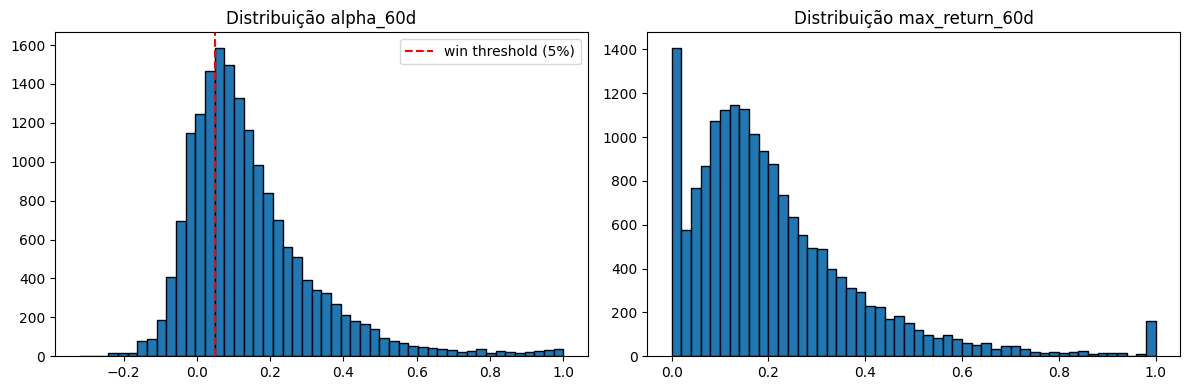

In [6]:
import matplotlib.pyplot as plt

print('=== Targets ===')
print(df_v31[['max_return_60d', 'max_drawdown_60d', 'spy_max_return_60d', 'alpha_60d']].describe().round(4))

win_rate = (df_v31['alpha_60d'] > 0.05).mean()
print(f'\nWin rate (alpha > 5%): {win_rate:.1%}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_v31['alpha_60d'].clip(-0.5, 1.0), bins=50, edgecolor='black')
axes[0].axvline(0.05, color='red', linestyle='--', label='win threshold (5%)')
axes[0].set_title('Distribuição alpha_60d')
axes[0].legend()
axes[1].hist(df_v31['max_return_60d'].clip(-0.5, 2.0), bins=50, edgecolor='black')
axes[1].set_title('Distribuição max_return_60d')
plt.tight_layout()
plt.show()


In [7]:
# Pode demorar 5-20 min.
from ml_training.models import build_model_configs
from ml_training.train import run_walk_forward_cv, summarize_results
from ml_training.config import N_FOLDS, PURGE_DAYS

model_configs = build_model_configs(feats_v31, feats_baseline)
print(f'Modelos: {list(model_configs.keys())}')

results, oof_pred, fold_specs = run_walk_forward_cv(
    df_v31=df_v31,
    model_configs=model_configs,
    n_folds=N_FOLDS,
    purge_days=PURGE_DAYS,
    min_train=100,
    min_test=20,
)

summary = summarize_results(results)
if summary.empty:
    raise RuntimeError('ERRO: Walk-forward CV sem resultados. Reduz min_train/min_test.')

print('\n=== Resultados CV ===')
display(summary.round(4))


Modelos: ['XGB-alpha-v31', 'LGBM-alpha-v31', 'RF-alpha-v31', 'Ridge-alpha-v31', 'XGB-alpha-baseline']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.82249e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.82249e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
2026-05-04 16:17:03,356 INFO | Fold  1 OK — n_train=9979 n_test=160
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feat


=== Resultados CV ===


,model,rho_alpha_mean,rho_alpha_std,rho_down_mean,topk_pnl_mean,topk_pnl_std,n_folds
0,XGB-alpha-v31,0.3331,0.1267,0.2344,0.1459,0.0688,10
1,LGBM-alpha-v31,0.3296,0.1429,0.2462,0.1505,0.0698,10
4,XGB-alpha-baseline,0.3228,0.1189,0.2048,0.1537,0.0673,10
2,RF-alpha-v31,0.3060,0.1063,0.2430,0.1512,0.0685,10
3,Ridge-alpha-v31,0.2976,0.1138,0.1857,0.1454,0.0656,10


In [8]:
from ml_training.train import select_champion, fit_isotonic_calibrator, train_full_champion
from ml_training.bundle import DipModelsV3, build_report, save_bundle, save_report
from ml_training.config import MOMENTUM_FEATURES, NEW_FEATURES_V31
from datetime import datetime

champion_name, champion_row = select_champion(summary)
print(f'Champion: {champion_name}')
print(f'  rho_alpha = {champion_row["rho_alpha_mean"]:.4f}')
print(f'  topk_pnl  = {champion_row["topk_pnl_mean"]:.4f}')

iso, brier, n_oof = fit_isotonic_calibrator(
    oof_pred[champion_name], df_v31['alpha_60d'].values, alpha_threshold=0.05
)
print(f'Calibrator: brier_oof={brier:.4f} | n_oof={n_oof}')

champ_alpha, champ_down, feats_used, n_train = train_full_champion(
    df_v31=df_v31, champion_cfg=model_configs[champion_name]
)
print(f'Treino full: {n_train} samples | {len(feats_used)} features')

bundle = DipModelsV3(
    model_up=champ_alpha,
    model_down=champ_down,
    feature_cols=feats_used,
    score_calibrator=iso,
    n_train_samples=int(n_train),
    train_date=datetime.utcnow().strftime('%Y-%m-%dT%H:%M:%SZ'),
    champion_name=champion_name,
    schema_version=3,
    momentum_feats=list(MOMENTUM_FEATURES),
    rho_mean=float(champion_row['rho_alpha_mean']),
    rho_alpha=float(champion_row['rho_alpha_mean']),
    rho_down=float(champion_row['rho_down_mean']),
    topk_pnl=float(champion_row['topk_pnl_mean']),
    fold_metrics=results[champion_name],
)

win_rate_alpha = float((df_v31['alpha_60d'] > 0.05).mean())
report = build_report(
    bundle=bundle,
    summary_df=summary,
    brier_oof=brier,
    win_rate_alpha=win_rate_alpha,
    n_folds_used=len(fold_specs),
    purge_days=PURGE_DAYS,
    horizon_days=HORIZON_DAYS,
    new_features=list(NEW_FEATURES_V31),
)

BUNDLE_PATH = Path(REPO_DIR) / 'dip_models_v3.pkl'
REPORT_PATH = Path(REPO_DIR) / 'ml_report_v3.json'
save_bundle(bundle, BUNDLE_PATH)
save_report(report, REPORT_PATH)
print(f'✓ Bundle: {BUNDLE_PATH.stat().st_size / 1024:.0f} KB')
print('✓ Report: ml_report_v3.json')


Champion: XGB-alpha-v31
  rho_alpha = 0.3331
  topk_pnl  = 0.1459
Calibrator: brier_oof=0.2252 | n_oof=6278


2026-05-04 16:36:27,141 INFO | Champion treinado em 17298 amostras com 34 features
/tmp/ipykernel_14459/1218545459.py:27: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  train_date=datetime.utcnow().strftime('%Y-%m-%dT%H:%M:%SZ'),
2026-05-04 16:36:27,174 INFO | [bundle] Escrito: /content/DipRadar/dip_models_v3.pkl (1234.3 KB)
2026-05-04 16:36:27,176 INFO | [report] Escrito: /content/DipRadar/ml_report_v3.json


Treino full: 17298 samples | 34 features
✓ Bundle: 1234 KB
✓ Report: ml_report_v3.json


In [9]:
import importlib
import ml_predictor as mp
importlib.reload(mp)

print(f'champion:   {bundle.champion_name}')
print(f'rho_alpha:  {bundle.rho_alpha:.4f}')
print(f'n_features: {len(bundle.feature_cols)}')
print(f'n_train:    {bundle.n_train_samples}')
print(f'train_date: {bundle.train_date}')
print(f'features:   {bundle.feature_cols}')

print('\n=== Smoke test (5 amostras) ===')
for _, row in df_v31.sample(5, random_state=42).iterrows():
    feats = {c: float(row[c]) for c in bundle.feature_cols}
    result = mp.ml_score(feats, symbol=row['ticker'])
    line = f'  {row["ticker"]:6s} | {row["alert_date"].date()} | label={result.label:10s} | pred_up={result.pred_up:+.3f} | alpha_real={row["alpha_60d"]:+.3f}'
    print(line)

info = mp.get_model_info()
assert info['champion'] == champion_name, f'ERRO: champion {info["champion"]} != {champion_name}'
assert info['n_features'] == len(bundle.feature_cols), f'ERRO: n_features {info["n_features"]} != {len(bundle.feature_cols)}'
print(f'\n✓ ml_predictor OK: champion={info["champion"]} | n_features={info["n_features"]}')


2026-05-04 16:37:07,462 INFO | [ml_predictor] Bundle v3 carregado — champion=XGB-alpha-v31 features=34 rho=0.33306969517931184


champion:   XGB-alpha-v31
rho_alpha:  0.3331
n_features: 34
n_train:    17298
train_date: 2026-05-04T16:36:27Z
features:   ['macro_score', 'vix', 'spy_drawdown_5d', 'sector_drawdown_5d', 'gross_margin', 'de_ratio', 'pe_vs_fair', 'analyst_upside', 'quality_score', 'drop_pct_today', 'drawdown_52w', 'rsi_14', 'atr_ratio', 'volume_spike', 'rsi_oversold_strength', 'vix_regime', 'pe_attractive', 'drop_x_drawdown', 'vol_x_drop', 'return_1m', 'return_3m_pre', 'sector_relative', 'beta_60d', 'return_5d', 'return_10d', 'return_20d', 'zscore_20d', 'distance_from_ma50', 'volatility_20d', 'sp500_trend', 'relative_drop', 'sector_alert_count_7d', 'days_since_52w_high', 'month_of_year']

=== Smoke test (5 amostras) ===
  HBAN   | 2020-09-21 | label=WIN_STRONG | pred_up=+0.281 | alpha_real=+0.290
  UU.L   | 2020-03-31 | label=WEAK       | pred_up=+0.049 | alpha_real=-0.053
  CLX    | 2018-02-02 | label=WIN_STRONG | pred_up=+0.178 | alpha_real=+0.059
  NVO    | 2009-02-27 | label=WIN_STRONG | pred_up=+0.

In [11]:
# Token: GitHub → Settings → Developer Settings → Personal Access Tokens
# Permissões mínimas: Contents (read + write)
import base64, requests
from getpass import getpass

GITHUB_TOKEN = getpass('')
OWNER  = 'romeurf'
REPO   = 'DipRadar'
BRANCH = 'main'

headers = {
    'Authorization': f'Bearer {GITHUB_TOKEN}',
    'Accept': 'application/vnd.github+json',
    'X-GitHub-Api-Version': '2022-11-28',
}

def _upload_file(local_path, repo_path, commit_msg):
    url = f'https://api.github.com/repos/{OWNER}/{REPO}/contents/{repo_path}'
    r = requests.get(url, headers=headers, params={'ref': BRANCH})
    sha = r.json().get('sha') if r.status_code == 200 else None
    with open(local_path, 'rb') as f:
        content_b64 = base64.b64encode(f.read()).decode()
    payload = {'message': commit_msg, 'content': content_b64, 'branch': BRANCH}
    if sha:
        payload['sha'] = sha
    r = requests.put(url, headers=headers, json=payload)
    r.raise_for_status()
    action = 'updated' if sha else 'created'
    print(f'✓ {repo_path} ({action}) — {Path(local_path).stat().st_size / 1024:.0f} KB')

ts = datetime.utcnow().strftime('%Y-%m-%d')
_upload_file(BUNDLE_PATH, 'dip_models_v3.pkl', f'chore(ml): retrain bundle v3.1 [{ts}] champion={champion_name} rho={bundle.rho_alpha:.3f}')
_upload_file(REPORT_PATH, 'ml_report_v3.json', f'chore(ml): update report v3.1 [{ts}]')
_upload_file(PARQUET_BASE, 'ml_training_merged.parquet', f'chore(ml): rebuild training dataset v3.1 [{ts}] n={len(df_v31)}')

print(f'\n✓ https://github.com/{OWNER}/{REPO}/tree/{BRANCH}')


KeyboardInterrupt: Interrupted by user